In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [43]:
vappadata = pd.read_csv("data1.csv")

In [44]:
vappadata.head()

,id,locale,code,gmt,order_fee,user_cash,weekdays
0,696579303,US,blogs,2016-06-06 23:19:45,0.0,0.0,0
1,800779946,US,blogs,2016-06-06 23:19:45,0.0,0.0,0
2,103349856,GB,blogs,2016-06-06 23:17:40,0.0,0.0,0
3,552621108,BD,blogs,2016-06-06 23:03:55,0.0,0.0,0
4,595126461,IN,blogs,2016-06-06 22:25:38,0.0,0.0,0


In [45]:
vappadata.loc[0:4]

,id,locale,code,gmt,order_fee,user_cash,weekdays
0,696579303,US,blogs,2016-06-06 23:19:45,0.0,0.0,0
1,800779946,US,blogs,2016-06-06 23:19:45,0.0,0.0,0
2,103349856,GB,blogs,2016-06-06 23:17:40,0.0,0.0,0
3,552621108,BD,blogs,2016-06-06 23:03:55,0.0,0.0,0
4,595126461,IN,blogs,2016-06-06 22:25:38,0.0,0.0,0


In [46]:
len(vappadata)

100

In [47]:
vappadata.describe()

,id,order_fee,user_cash,weekdays
count,1.000000e+02,100.00000,100.000000,100.0
mean,4.652260e+08,1.10622,131.855010,0.0
std,2.661673e+08,3.32176,404.572128,0.0
min,1.697799e+07,0.00000,0.000000,0.0
25%,2.361449e+08,0.00000,0.000000,0.0
50%,4.474265e+08,0.00000,0.000000,0.0
75%,7.004547e+08,0.00000,0.000000,0.0
max,9.789907e+08,13.85900,2179.561000,0.0


In [48]:
vappadata[vappadata.locale.isnull()]

,id,locale,code,gmt,order_fee,user_cash,weekdays
6,176944844,NaN,blogs,2016-06-06 21:33:06,0.0,0.0,0


In [49]:
vappadata.dtypes

id             int64
locale           str
code             str
gmt              str
order_fee    float64
user_cash    float64
weekdays       int64
dtype: object

In [50]:
vappadata

,id,locale,code,gmt,order_fee,user_cash,weekdays
0,696579303,US,blogs,2016-06-06 23:19:45,0.0,0.0,0
1,800779946,US,blogs,2016-06-06 23:19:45,0.0,0.0,0
2,103349856,GB,blogs,2016-06-06 23:17:40,0.0,0.0,0
3,552621108,BD,blogs,2016-06-06 23:03:55,0.0,0.0,0
4,595126461,IN,blogs,2016-06-06 22:25:38,0.0,0.0,0
...,...,...,...,...,...,...,...
95,563462378,BD,blogs,2016-06-06 00:16:35,0.0,0.0,0
96,888775497,DE,blogs,2016-06-05 23:32:16,0.0,0.0,0
97,223814138,US,blogs,2016-06-05 23:15:46,0.0,0.0,0
98,835159146,US,blogs,2016-06-05 22:34:10,0.0,0.0,0


In [ ]:
meta = pd.read_csv("country_region_data.csv", sep=";")

In [52]:
meta

,Country_Long,Country_Short,Region
0,Singapore,SG,Others
1,United Kingdom,GB,EU
2,United Kingdom,GB,EU
3,United Arab Emirates,AE,MEA
4,United States,US,Others
...,...,...,...
95,Canada,CA,Others
96,United Arab Emirates,AE,MEA
97,India,IN,Others
98,Germany,DE,EU


In [53]:
vappadata.locale.unique()

<StringArray>
['US', 'GB', 'BD', 'IN', 'SG', nan, 'MY', 'BG', 'AE', 'CA', 'DE']
Length: 11, dtype: str

In [54]:
joindf = pd.merge(vappadata,meta,how="left",left_on="locale",right_on="Country_Short")

In [55]:
joindf

,id,locale,code,gmt,order_fee,user_cash,weekdays,Country_Long,Country_Short,Region
0,696579303,US,blogs,2016-06-06 23:19:45,0.0,0.0,0,United States,US,Others
1,696579303,US,blogs,2016-06-06 23:19:45,0.0,0.0,0,United States,US,Others
2,696579303,US,blogs,2016-06-06 23:19:45,0.0,0.0,0,United States,US,Others
3,696579303,US,blogs,2016-06-06 23:19:45,0.0,0.0,0,United States,US,Others
4,696579303,US,blogs,2016-06-06 23:19:45,0.0,0.0,0,United States,US,Others
...,...,...,...,...,...,...,...,...,...,...
998,757704681,IN,blogs,2016-06-05 22:34:10,0.0,0.0,0,India,IN,Others
999,757704681,IN,blogs,2016-06-05 22:34:10,0.0,0.0,0,India,IN,Others
1000,757704681,IN,blogs,2016-06-05 22:34:10,0.0,0.0,0,India,IN,Others
1001,757704681,IN,blogs,2016-06-05 22:34:10,0.0,0.0,0,India,IN,Others


In [56]:
countdf = joindf.groupby("Region").count()

<Axes: >

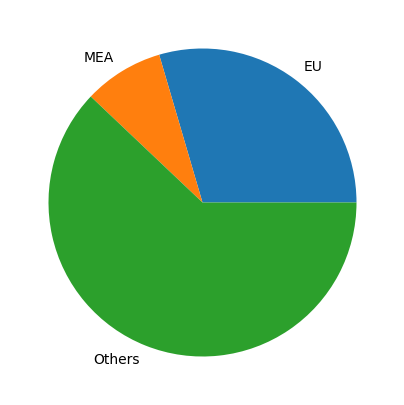

In [57]:
countdf.locale.plot(kind="pie", figsize=(14, 5))

<Axes: xlabel='locale'>

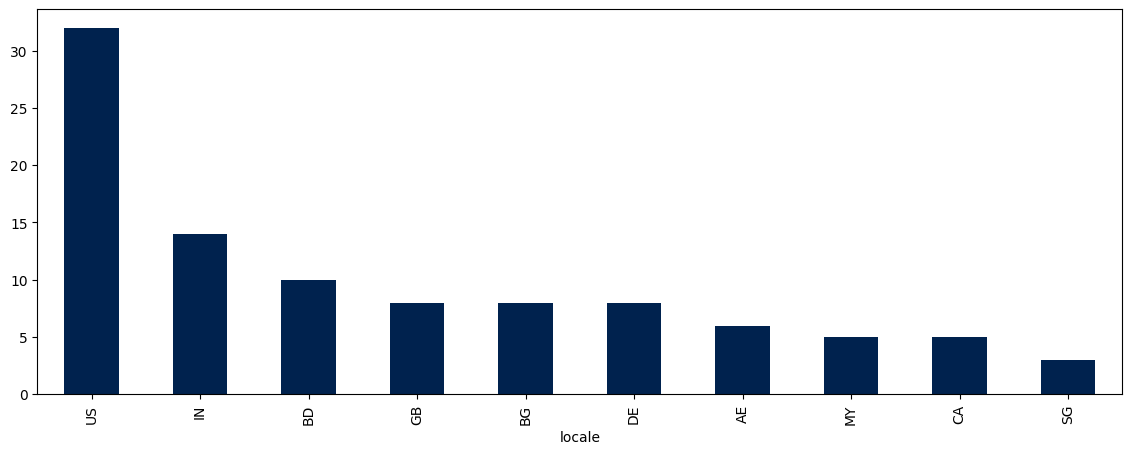

In [58]:
vappadata.locale.value_counts().plot(kind="bar", figsize=(14, 5), colormap="cividis")

In [59]:
vappadata.gmt

0     2016-06-06 23:19:45
1     2016-06-06 23:19:45
2     2016-06-06 23:17:40
3     2016-06-06 23:03:55
4     2016-06-06 22:25:38
             ...         
95    2016-06-06 00:16:35
96    2016-06-05 23:32:16
97    2016-06-05 23:15:46
98    2016-06-05 22:34:10
99    2016-06-05 22:34:10
Name: gmt, Length: 100, dtype: str

In [30]:
vappadata.gmt = pd.to_datetime(vappadata.gmt)

In [38]:
weekdays = vappadata.gmt.dt.weekday

In [39]:
weekdays

0     0
1     0
2     0
3     0
4     0
     ..
95    0
96    6
97    6
98    6
99    6
Name: gmt, Length: 100, dtype: int32

In [64]:
vappadata = vappadata.drop(columns=["weekdays"])

In [66]:
vappadata = vappadata.assign(weekday=weekdays)

In [67]:
vappadata

,id,locale,code,gmt,order_fee,user_cash,weekday
0,696579303,US,blogs,2016-06-06 23:19:45,0.0,0.0,0
1,800779946,US,blogs,2016-06-06 23:19:45,0.0,0.0,0
2,103349856,GB,blogs,2016-06-06 23:17:40,0.0,0.0,0
3,552621108,BD,blogs,2016-06-06 23:03:55,0.0,0.0,0
4,595126461,IN,blogs,2016-06-06 22:25:38,0.0,0.0,0
...,...,...,...,...,...,...,...
95,563462378,BD,blogs,2016-06-06 00:16:35,0.0,0.0,0
96,888775497,DE,blogs,2016-06-05 23:32:16,0.0,0.0,6
97,223814138,US,blogs,2016-06-05 23:15:46,0.0,0.0,6
98,835159146,US,blogs,2016-06-05 22:34:10,0.0,0.0,6


In [68]:
vappadata.groupby("weekday").count()

,id,locale,code,gmt,order_fee,user_cash
weekday,,,,,,
0,96,95,96,96,96,96
6,4,4,4,4,4,4


In [69]:
meta

,Country_Long,Country_Short,Region
0,Singapore,SG,Others
1,United Kingdom,GB,EU
2,United Kingdom,GB,EU
3,United Arab Emirates,AE,MEA
4,United States,US,Others
...,...,...,...
95,Canada,CA,Others
96,United Arab Emirates,AE,MEA
97,India,IN,Others
98,Germany,DE,EU
